In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_sales_data.csv to cleaned_sales_data (1).csv


In [ ]:
import pandas as pd

df = pd.read_csv('cleaned_sales_data.csv')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Year,Month,Month Name,Shipping Days
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,November,3
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,November,3
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,June,4
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,October,7
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,October,7


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load cleaned dataset
df = pd.read_csv('cleaned_sales_data.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Create visualization columns
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()

print("Dataset ready:", df.shape)


Dataset ready: (9789, 22)


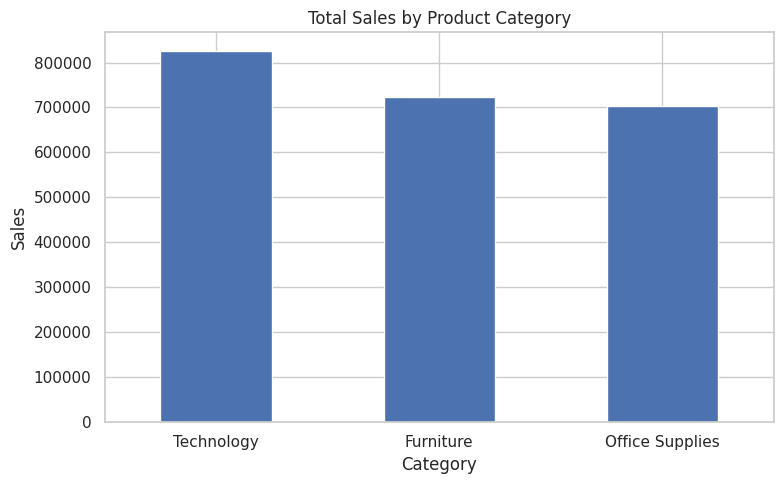

In [ ]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
category_sales.plot(kind='bar')

plt.title('Total Sales by Product Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

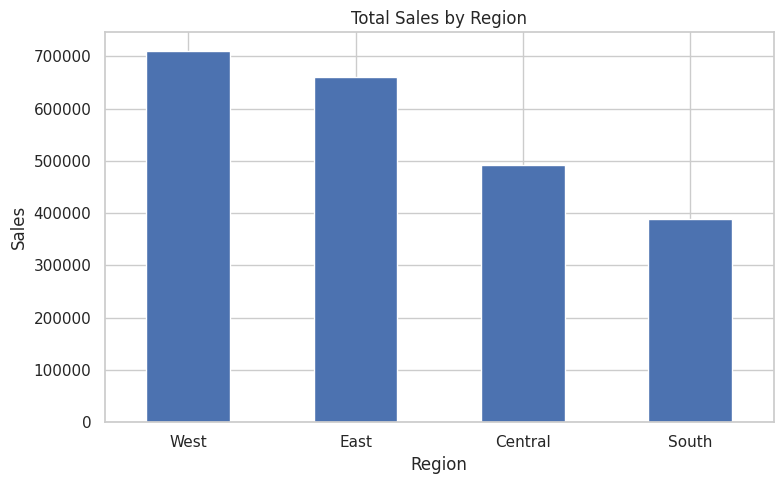

In [ ]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
region_sales.plot(kind='bar')

plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

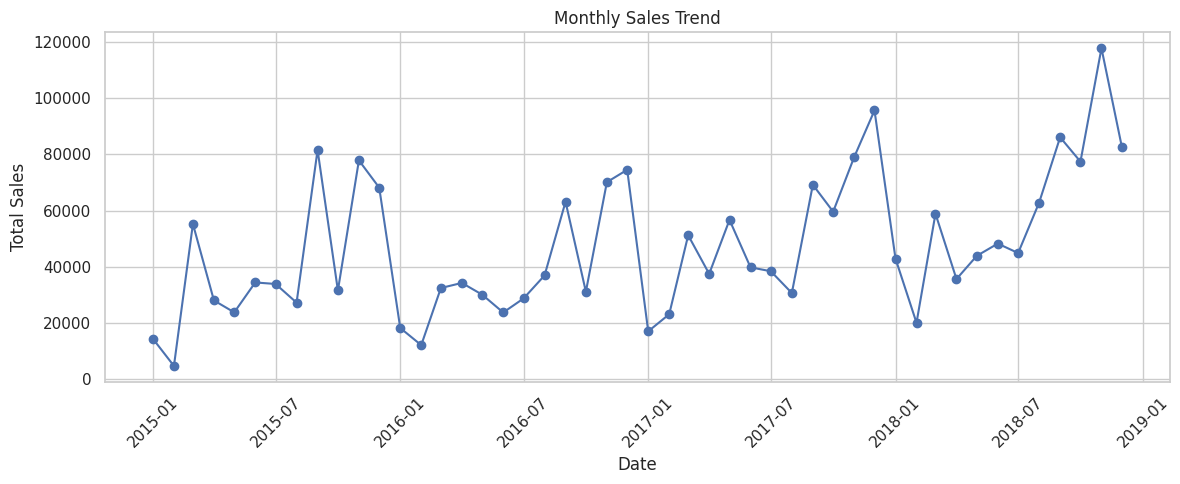

In [ ]:
monthly_sales = df.groupby(
    df['Order Date'].dt.to_period('M')
)['Sales'].sum()

monthly_sales.index = monthly_sales.index.to_timestamp()

plt.figure(figsize=(12, 5))
plt.plot(monthly_sales.index, monthly_sales.values, marker='o')

plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

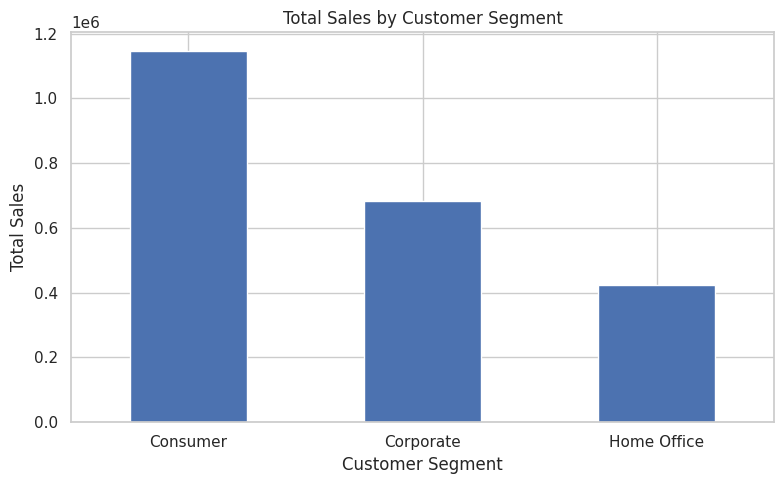

In [ ]:
segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
segment_sales.plot(kind='bar')

plt.title('Total Sales by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

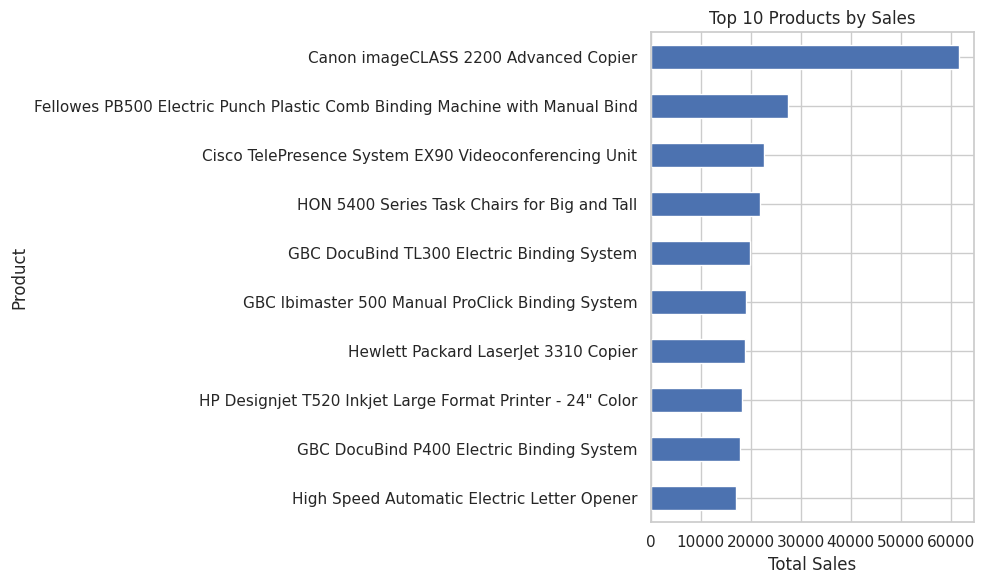

In [ ]:
top_products = (
    df.groupby('Product Name')['Sales']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 6))
top_products.plot(kind='barh')

plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

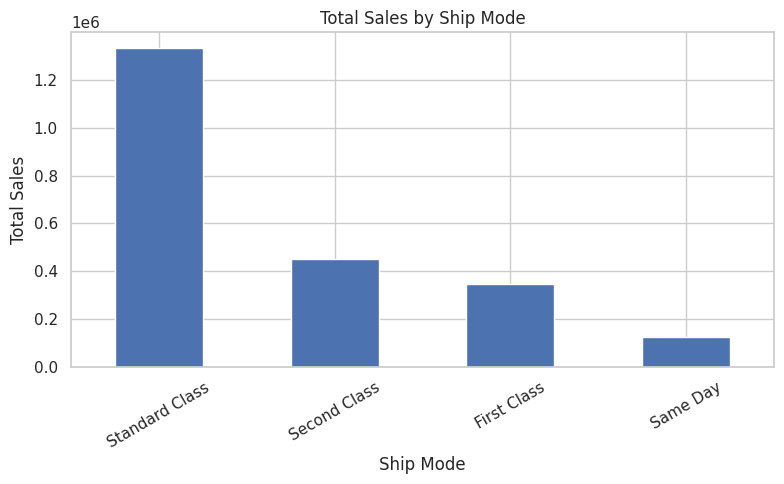

In [ ]:
ship_mode_sales = df.groupby('Ship Mode')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
ship_mode_sales.plot(kind='bar')

plt.title('Total Sales by Ship Mode')
plt.xlabel('Ship Mode')
plt.ylabel('Total Sales')
plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

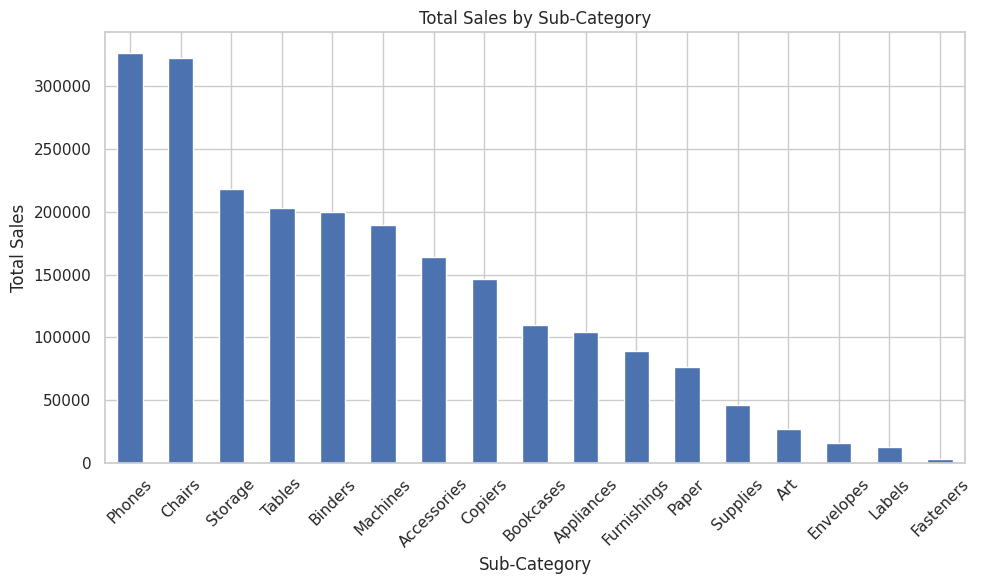

In [ ]:
subcategory_sales = (
    df.groupby('Sub-Category')['Sales']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))
subcategory_sales.plot(kind='bar')

plt.title('Total Sales by Sub-Category')
plt.xlabel('Sub-Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

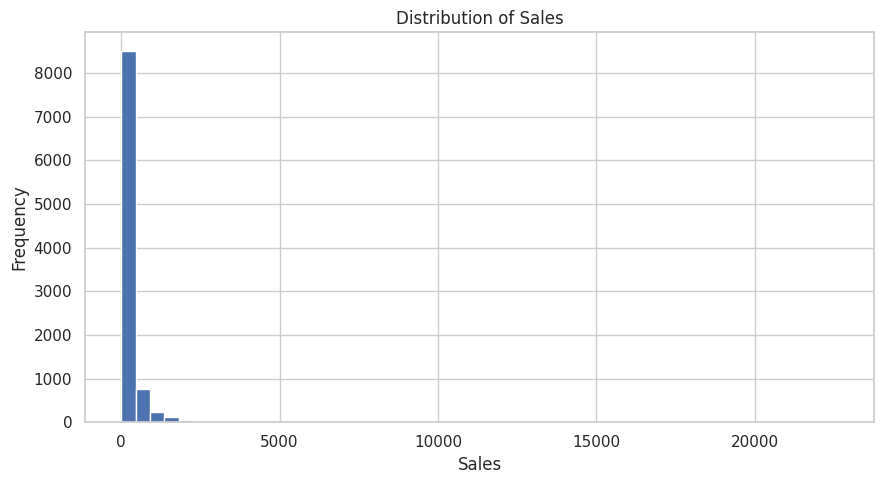

In [ ]:
plt.figure(figsize=(9, 5))

plt.hist(df['Sales'], bins=50)

plt.title('Distribution of Sales')
plt.xlabel('Sales')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

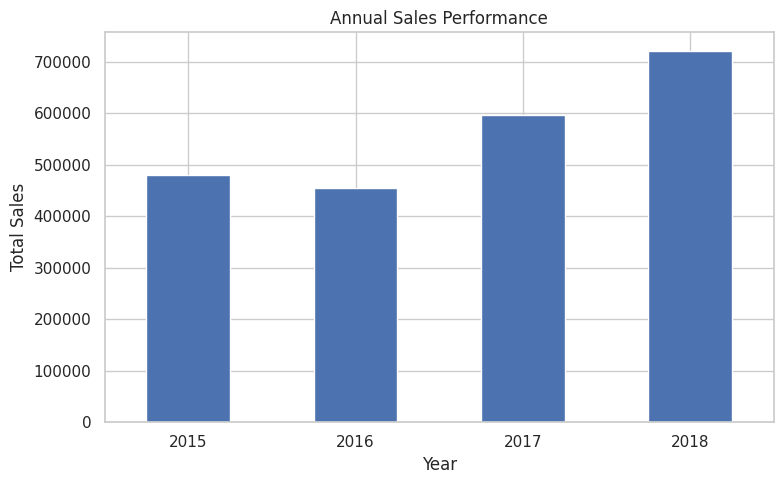

In [ ]:
yearly_sales = df.groupby('Year')['Sales'].sum()

plt.figure(figsize=(8, 5))
yearly_sales.plot(kind='bar')

plt.title('Annual Sales Performance')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Key findings

best_category = category_sales.idxmax()
best_region = region_sales.idxmax()
best_segment = segment_sales.idxmax()
best_ship_mode = ship_mode_sales.idxmax()
best_subcategory = subcategory_sales.idxmax()
best_year = yearly_sales.idxmax()
top_product = top_products.idxmax()

print("KEY INSIGHTS")
print("-" * 40)
print("Top Category:", best_category)
print("Top Region:", best_region)
print("Top Customer Segment:", best_segment)
print("Most Used Ship Mode by Sales:", best_ship_mode)
print("Top Sub-Category:", best_subcategory)
print("Best Sales Year:", best_year)
print("Top Product:", top_product)

KEY INSIGHTS
----------------------------------------
Top Category: Technology
Top Region: West
Top Customer Segment: Consumer
Most Used Ship Mode by Sales: Standard Class
Top Sub-Category: Phones
Best Sales Year: 2018
Top Product: Canon imageCLASS 2200 Advanced Copier


In [ ]:
df.to_csv('Data_Visualization_Cleaned.csv', index=False)

print("Visualization dataset saved successfully!")

Visualization dataset saved successfully!
